In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)

from gerrychain.proposals import recom, propose_random_flip

from gerrychain.tree import recursive_tree_part, recursive_seed_part

from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias

from gerrychain.updaters import cut_edges

from gerrychain.tree import bipartition_tree, find_balanced_edge_cuts_memoization


from collections import Counter
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx


In [3]:
df = gpd.read_file("../SC_Processed/output/SC_Processed_Precincts_ALARM.shp")
graph = Graph.from_geodataframe(df)

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:457: UserWarning: NA values found in column muni!
  warnings.warn("NA values found in column {}!".format(column))


(371616.90050833, 863374.3231278701, 164.5251800149963, 393815.45853008504)

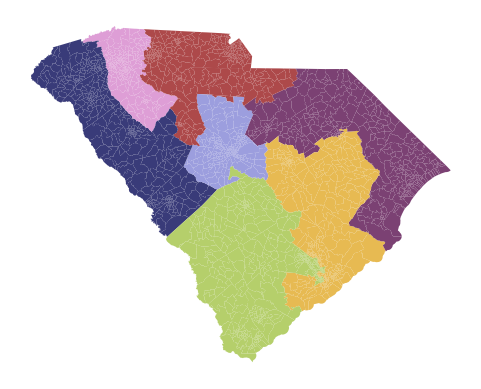

In [4]:
smc_plans = pd.read_csv("./sc_alarm_plans.csv")

smc_plans.rename(columns={"Unnamed: 0":"GEOID"},inplace=True)

smc_plans["GEOID"] = smc_plans["GEOID"].astype("str")

df = df.merge(smc_plans,on="GEOID")

df.plot(column="V123",cmap="tab20b")
plt.axis('off')

In [5]:
def polsby_popper_gdf(gdf):
    return 4*math.pi * gdf.area/(gdf.length**2)

def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    current = df.index.map(partition.assignment)

    return df.assign(current=current).groupby("county")["current"].nunique().gt(1).sum()

election_names = [
    "PRE",
    "USS"
]

num_elections = len(election_names)

election_columns = [
  ['pr_20_r_','pr_20_d_'],
  ['uss_20_r_','uss_20_d_']
]

my_updaters = {
    "population": updaters.Tally("pop", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_pp_blck"] = graph.nodes()[node]["pop"] - graph.nodes()[node]["pp_blck"]

my_updaters.update({"pp_blck": Election("pp_blck", {"pp_blck": "pp_blck", "non_pp_blck": "non_pp_blck"})})

# save percentages

my_updaters.update(election_updaters)


In [6]:
cs = [] # county splits
mms = [] # mean median
egs = [] # efficiency gap
pbs = [] # partisan bias
dvp = [] # dem voting perc
pps = [] # polsby popper
bvp = [] # black voting percent
mbvp = [] # max black voting percent
wins = [] # dem wins


for i in range(1,5001): # num of trees to generate
    tree_partition = GeographicPartition(graph, df[f"V{i}"], my_updaters)

    cs.append(tree_partition['county_splits'])
    mms.append(mean_median(tree_partition['PRE']))
    egs.append(efficiency_gap(tree_partition['PRE']))
    pbs.append(partisan_bias(tree_partition['PRE']))
    dvp.append(sorted(tree_partition['PRE'].percents("Democratic")))
    pps.append(sum([1/x for x in polsby_popper(tree_partition).values()])/7)
    bvp.append(sorted(tree_partition['pp_blck'].percents("pp_blck")))
    mbvp.append(max(bvp[-1]))
    wins.append(tree_partition['PRE'].wins("Democratic"))

    if i <= 100:
        #df['current'] = df["GEOID"].map(cd_dict)
        df.plot(column=f'V{i}',cmap='tab20b')
        plt.axis('off')
        plt.savefig(f'./SC_ALARM_Ensemble_graph/df_plot_{i}.png')
        plt.close()
"""
    plt.figure(figsize=(10,4))
    nx.draw(graph, pos={x:(graph.nodes()[x]['C_X'], graph.nodes()[x]['C_Y']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap ='tab20b',node_size=15)
    plt.savefig(f'./NC_First_Ensemble_gif/network_plot_{i}.png')
    plt.close()

    df['current'] = df["PRECINCTID"].map(cd_dict)
    df.plot(column='current',cmap='tab20b')
    plt.axis('off')
    plt.savefig(f'./NC_First_Ensemble_gif/df_plot{i}.png')
    plt.close()
"""


'\n    plt.figure(figsize=(10,4))\n    nx.draw(graph, pos={x:(graph.nodes()[x][\'C_X\'], graph.nodes()[x][\'C_Y\']) for x in graph.nodes()}, node_color=[cd_dict[x] for x in graph.nodes()],cmap =\'tab20b\',node_size=15)\n    plt.savefig(f\'./NC_First_Ensemble_gif/network_plot_{i}.png\')\n    plt.close()\n\n    df[\'current\'] = df["PRECINCTID"].map(cd_dict)\n    df.plot(column=\'current\',cmap=\'tab20b\')\n    plt.axis(\'off\')\n    plt.savefig(f\'./NC_First_Ensemble_gif/df_plot{i}.png\')\n    plt.close()\n'

In [10]:
import csv

with open(f"./SC_ALARM_Ensemble_stats/DemPercs.csv","w") as tf1:
    writer = csv.writer(tf1, lineterminator="\n")
    writer.writerows(dvp)

with open(f"./SC_ALARM_Ensemble_stats/BlackPerc.csv","w") as tf1:
    writer = csv.writer(tf1, lineterminator="\n")
    writer.writerows(bvp)

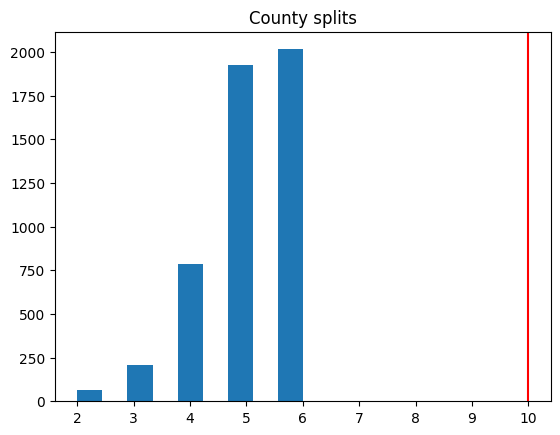

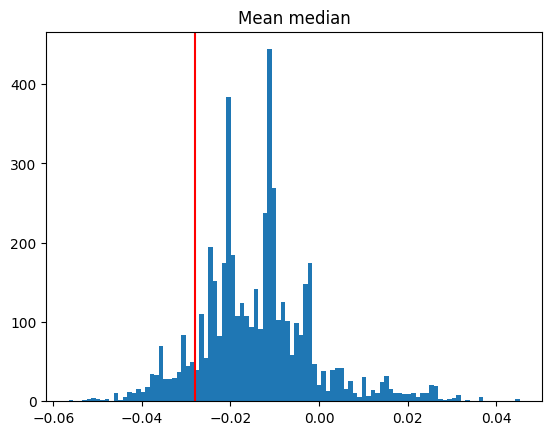

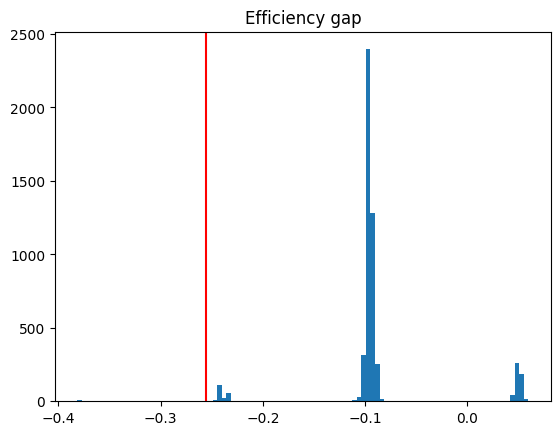

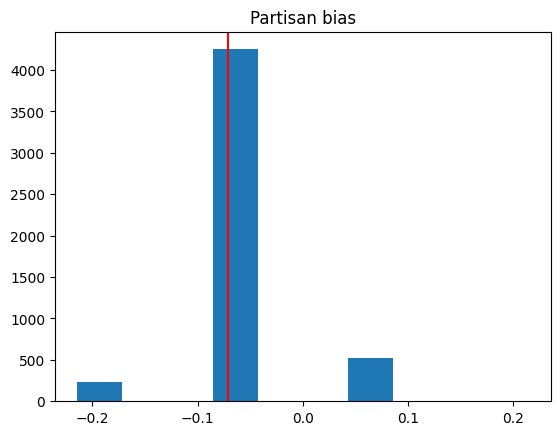

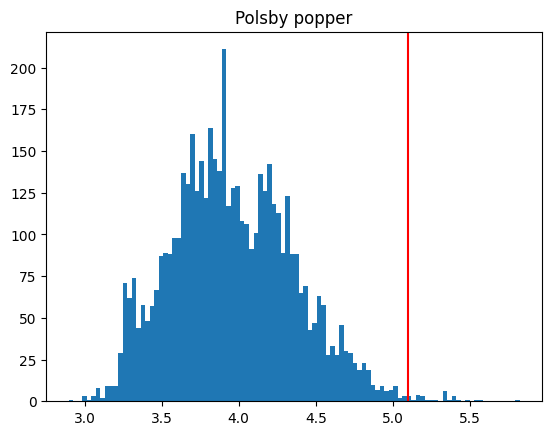

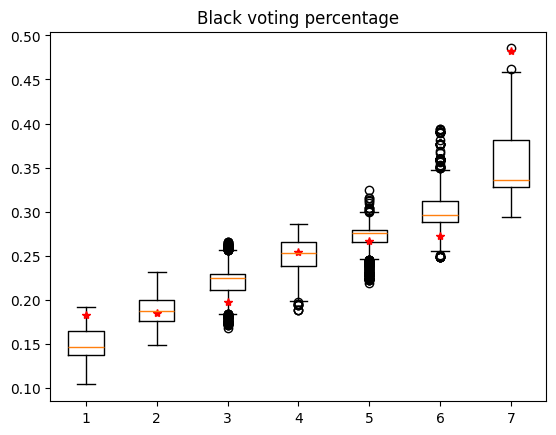

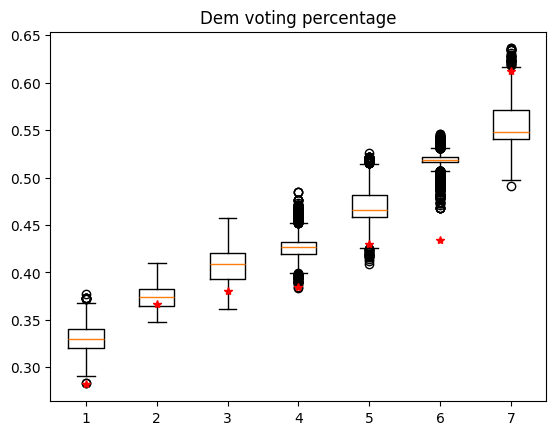

In [8]:
plt.hist(cs, bins=9)
plt.axvline(10, color='red',label='Enacted')
plt.title("County splits")
plt.show()

plt.hist(mms,bins=100)
plt.axvline(-0.02801788672558564, color='red',label='Enacted')
plt.title("Mean median")
plt.show()

plt.hist(egs,bins=100)
plt.axvline(-0.25611450640053, color='red',label='Enacted')
plt.title("Efficiency gap")
plt.show()

plt.hist(pbs)
plt.axvline(-0.07142857142857145, color='red',label='Enacted')
plt.title("Partisan bias")
plt.show()

plt.hist(pps,bins=100)
plt.axvline(5.098875308592818, color='red',label='Enacted')
plt.title("Polsby popper")
plt.show()

bvp = np.array(bvp)
plt.boxplot(bvp)
plt.plot(range(1,8),sorted([0.1828165961087225,
 0.18492617005629175,
 0.19797997475993911,
 0.25449946333226225,
 0.2663038733124516,
 0.2726958300124814,
 0.4819280068798886]), "*", color='red',label='NH_Black')
plt.title("Black voting percentage")
plt.show()

dvp = np.array(dvp)
plt.boxplot(dvp)
plt.plot(range(1,8),
         sorted([0.28192461872153896,
                 0.3668851460292951,
                 0.3802530715562839,
                 0.3849554396261276, 
                 0.42982538776550644,
                 0.43424330297262426,
                 0.6127263177906164]),"*", color='red',label='Enacted')
plt.title("Dem voting percentage")
plt.show()